### Writing down what Lohani does

Combination of pure and mixed states generated in Lohanis

Will use only mixed states here for simplicity - generated using the Ginibre ensemble 
$$
G = N(0,1) + i\,N(0,1), \quad 
\rho = \frac{G G^{\dagger}}{\mathrm{Tr}(G G^{\dagger})}
$$

Noise generated by rotating each projector by a random unitary with angles drawn from gaussian with mean of zero (small misalignments)

36 distinct projectors are used in Lohanis paper:

$$
\begin{aligned}
|H\rangle &= 
\begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad 
|V\rangle = 
\begin{bmatrix} 0 \\ 1 \end{bmatrix}, \\
|D\rangle &= \tfrac{1}{\sqrt{2}} (|H\rangle + |V\rangle), \quad 
|A\rangle = \tfrac{1}{\sqrt{2}} (|H\rangle - |V\rangle), \\
|R\rangle &= \tfrac{1}{\sqrt{2}} (|H\rangle + i|V\rangle), \quad 
|L\rangle = \tfrac{1}{\sqrt{2}} (|H\rangle - i|V\rangle).
\end{aligned}
$$

The corresponding projectors are:

$$
h = |H\rangle\langle H|,\quad
v = |V\rangle\langle V|,\quad
d = |D\rangle\langle D|,\quad
a = |A\rangle\langle A|,\quad
r = |R\rangle\langle R|,\quad
l = |L\rangle\langle L|.
$$


The full two-qubit tomography measurement matrix \( P \) used in simulation is:

$$
P =
\begin{bmatrix}
h\!\otimes\!h & h\!\otimes\!v & v\!\otimes\!v & v\!\otimes\!h & v\!\otimes\!r & v\!\otimes\!l \\
h\!\otimes\!l & h\!\otimes\!r & h\!\otimes\!d & h\!\otimes\!a & v\!\otimes\!a & v\!\otimes\!d \\
a\!\otimes\!d & a\!\otimes\!a & d\!\otimes\!a & d\!\otimes\!d & d\!\otimes\!r & d\!\otimes\!l \\
a\!\otimes\!l & a\!\otimes\!r & a\!\otimes\!h & a\!\otimes\!v & d\!\otimes\!v & d\!\otimes\!h \\
r\!\otimes\!h & r\!\otimes\!v & l\!\otimes\!v & l\!\otimes\!h & l\!\otimes\!r & l\!\otimes\!l \\
r\!\otimes\!l & r\!\otimes\!r & r\!\otimes\!d & r\!\otimes\!a & l\!\otimes\!a & l\!\otimes\!d
\end{bmatrix}
$$


Each projector $ P_{ij} $ acts on the 2-qubit Hilbert space as:
$
M_{ij} = \mathrm{Tr}(\rho\,P_{ij}),
$
producing one of the 36 tomographic measurement probabilities.

CNN used not standard NN

Outputs 16 real numbers that are arranged as lower triangular tau matrix
Can get desnity matrix back using
$$
\rho_{\text{pred}} = \frac{\tau_{\text{pred}}^{\dagger} \tau_{\text{pred}}}
{\mathrm{Tr}(\tau_{\text{pred}}^{\dagger} \tau_{\text{pred}})}
$$


NN process

- simulate noisy measurements from $ P $
- feed 6x6 to the CNN
- CNN outputs tau matrix
- compute $ \rho $ from this 
- compare predicted and true rho for fidelity
- train CNN

Repeated with different training dataset sizes to see how fidelity scales

Max pooling: downsample feature maps by taking maximum value in each small region - focuses on dominant features
Dropout: randomly turns off a fraction of neurons to prevent overfitting

^^ interesting techniques

Kernel: scans over input (2x2 used)
Stride: how far filter moves (1 used)
Feature maps: num of filters applied (25 used)
Zero padding: adds zeros at eaches so dimensions are consistent
ReLU used

fully connected layers with 720 and 450 neurons

tau matrix used as output to ensure positive semidefinite and normalised

### 6x6 Projector matrix P

In [3]:
import numpy as np

# Single-qubit basis states
H = np.array([[1.0], [0.0]], dtype=complex)
V = np.array([[0.0], [1.0]], dtype=complex)

D = (H + V) / np.sqrt(2)
A = (H - V) / np.sqrt(2)
R = (H + 1j*V) / np.sqrt(2)
L = (H - 1j*V) / np.sqrt(2)

def proj(ket):
    return ket @ ket.conj().T

h = proj(H)
v = proj(V)
d = proj(D)
a = proj(A)
r = proj(R)
l = proj(L)

projs = [h, v, d, a, r, l]  # List of projection matrices

In [4]:
P = np.empty((6,6), dtype=object)

for i in range(6):
    for j in range(6):
        P[i,j] = np.kron(projs[i], projs[j])

### Generating Ginibre State and finding noisy measurements

In [7]:
def random_mixed_state():
    G = (np.random.normal(size=(4, 4)) 
         + 1j * np.random.normal(size=(4, 4)))
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return rho

In [10]:
# Lohani samples Euler angles from N(0, sigma)
def noisy_unitary(sigma):
    theta, phi, zeta = np.random.normal(0, sigma, 3)
    U = np.array([
        [np.exp(1j*phi/2)*np.cos(theta), -1j*np.exp(1j*zeta)*np.sin(theta)],
        [-1j*np.exp(-1j*zeta)*np.sin(theta), np.exp(-1j*phi/2)*np.cos(theta)]
    ], dtype=complex)
    return U

def rotate_projector(P, sigma):
    U1 = noisy_unitary(sigma)
    U2 = noisy_unitary(sigma)
    U = np.kron(U1, U2)
    return U @ P @ U.conj().T

In [ ]:
def measure_state(rho, P, sigma):

    M = np.empty((6,6), dtype=float)
    for i in range(6):
        for j in range(6):
            P_noisy = rotate_projector(P[i,j], sigma)
            M[i, j] = np.real(np.trace(rho @ P_noisy))
    return M

### Generate N random states + their measurements + targets

In [14]:
def generate_dataset(N, P, sigma):
    X = np.zeros((N, 36), dtype=np.float32)
    Y = np.zeros((N, 32), dtype=np.float32)

    for k in range(N):
        rho = random_mixed_state()
        M = measure_state(rho, P, sigma)
        X[k] = M.reshape(-1)

        rho_flat = rho.reshape(-1)
        Y[k, :16] = np.real(rho_flat)
        Y[k, 16:] = np.imag(rho_flat) # imag parts seperate, so 32 outputs, 16 for real, 16 for imag

    return X, Y

In [20]:
# We also need a function to find fidelity between two density matrices
from scipy.linalg import sqrtm

def fidelity_from_output(pred, true):
    pred_rho = pred[:16] + 1j * pred[16:]
    true_rho = true[:16] + 1j * true[16:]

    pred_rho = pred_rho.reshape(4, 4)
    true_rho = true_rho.reshape(4, 4)

    pred_rho = (pred_rho + pred_rho.conj().T) / 2
    true_rho = (true_rho + true_rho.conj().T) / 2
    pred_rho /= np.trace(pred_rho)
    true_rho /= np.trace(true_rho)

    sqrt_true = sqrtm(true_rho)
    inner = sqrt_true @ pred_rho @ sqrt_true
    F = np.real(np.trace(sqrtm(inner)) ** 2)
    return float(np.clip(F, 0, 1))

### Start with standard sequential NN to test

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

def make_model():
    model = nn.Sequential(
        nn.Linear(36, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.5),   # reduce overfitting
        nn.Linear(64, 32)  # 32 = 16 Re + 16 Im of rho
    )
    return model

def train_and_eval_for_N(N, P, sigma, n_epochs=200, lr=1e-3):

    X, Y = generate_dataset(N, P, sigma)
    
    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]
    
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))
    Y_test_t  = torch.from_numpy(Y_test.astype(np.float32))

    model = make_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, Y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).numpy()

    fids = []
    for k in range(len(pred_test)):
        f = fidelity_from_output(pred_test[k], Y_test[k])
        fids.append(f)

    avg_fid = float(np.mean(fids))
    print(f"N={N}, Average Test Fidelity={avg_fid:.6e}")
    return avg_fid


#### NOTE: currently ouputting directly to rho not tau - change later - 16 outputs and chagne fidelity and true output

In [33]:
N_list = np.linspace(20,200,10, dtype=int)
sigma  = 0.1

avg_fids = []

for N in N_list:
    print(f"\n=== Running experiment for N = {N} ===")
    avg_fid = train_and_eval_for_N(N, P, sigma, n_epochs=200, lr=1e-3)
    avg_fids.append(avg_fid)


=== Running experiment for N = 20 ===
N=20, Average Test Fidelity=8.012681e-01

=== Running experiment for N = 40 ===
N=40, Average Test Fidelity=8.485386e-01

=== Running experiment for N = 60 ===
N=60, Average Test Fidelity=8.735777e-01

=== Running experiment for N = 80 ===
N=80, Average Test Fidelity=8.279386e-01

=== Running experiment for N = 100 ===
N=100, Average Test Fidelity=8.791048e-01

=== Running experiment for N = 120 ===
N=120, Average Test Fidelity=8.604708e-01

=== Running experiment for N = 140 ===
N=140, Average Test Fidelity=8.324262e-01

=== Running experiment for N = 160 ===
N=160, Average Test Fidelity=8.710331e-01

=== Running experiment for N = 180 ===
N=180, Average Test Fidelity=8.702113e-01

=== Running experiment for N = 200 ===
N=200, Average Test Fidelity=8.661487e-01


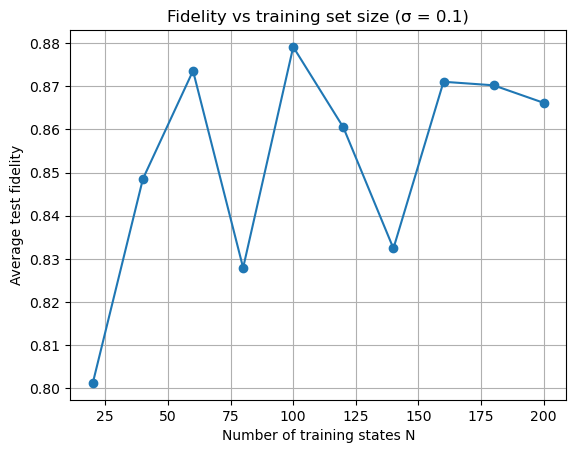

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(N_list, avg_fids, marker='o')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma})")
plt.grid(True)
plt.show()